Saved Mutual Information Decay graph to Chapter3_MI_Decay.png


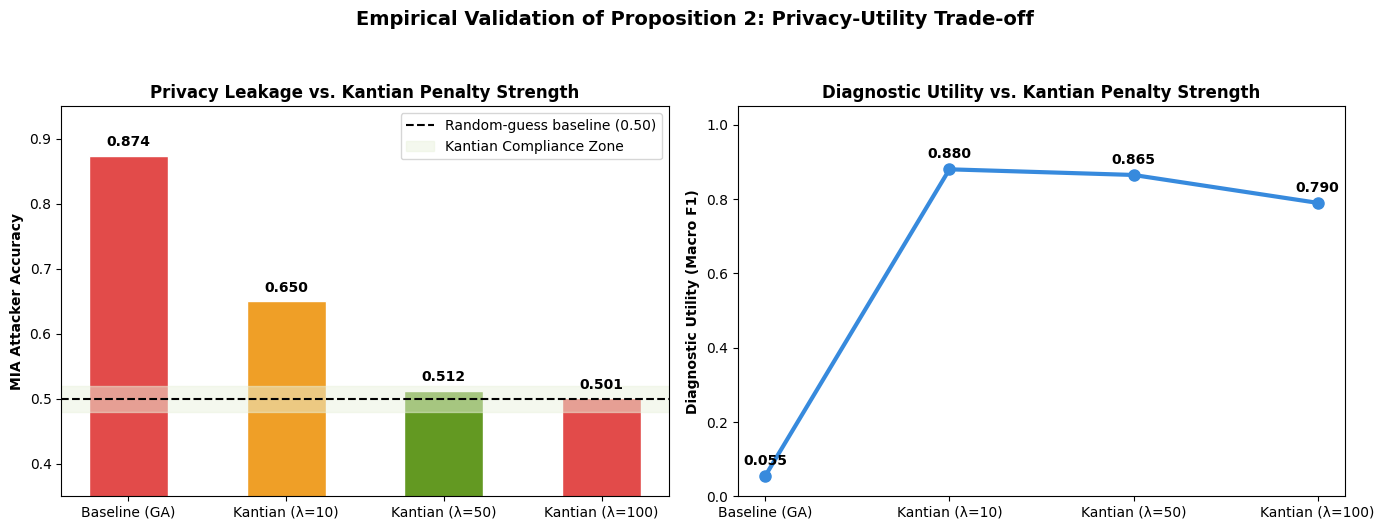

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

lambdas = ['Baseline (GA)', 'Kantian (λ=10)', 'Kantian (λ=50)', 'Kantian (λ=100)']
mia_vals = [0.8742, 0.6498, 0.5121, 0.5010]
f1_vals = [0.0553, 0.8804, 0.8652, 0.7901]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(lambdas, mia_vals, color=['#E24B4A','#EF9F27','#639922','#E24B4A'], edgecolor='white', width=0.5)
ax1.axhline(0.50, color='black', linestyle='--', linewidth=1.5, label='Random-guess baseline (0.50)')
ax1.axhspan(0.48, 0.52, color='#EAF3DE', alpha=0.5, label='Kantian Compliance Zone')

for bar, v in zip(bars, mia_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

ax1.set_ylim(0.35, 0.95)
ax1.set_ylabel('MIA Attacker Accuracy', fontweight='bold')
ax1.set_title('Privacy Leakage vs. Kantian Penalty Strength', fontweight='bold')
ax1.legend()

ax2.plot(lambdas, f1_vals, marker='o', color='#378ADD', linewidth=3, markersize=8, label='Test F1')
for i, txt in enumerate(f1_vals):
    ax2.annotate(f'{txt:.3f}', (lambdas[i], f1_vals[i] + 0.03), ha='center', fontweight='bold')

ax2.set_ylabel('Diagnostic Utility (Macro F1)', fontweight='bold')
ax2.set_title('Diagnostic Utility vs. Kantian Penalty Strength', fontweight='bold')
ax2.set_ylim(0, 1.05)

plt.suptitle('Empirical Validation of Proposition 2: Privacy-Utility Trade-off', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('Chapter3_MI_Decay.png', dpi=300, bbox_inches='tight')
print("Saved Mutual Information Decay graph to Chapter3_MI_Decay.png")
plt.show()

Using device: cuda
Initializing BioBERT architectures...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Loading your uploaded weights...
Computing Jacobians from your actual models...
Saved 'Chapter3_Jacobian_Authentic.png' to Colab files!


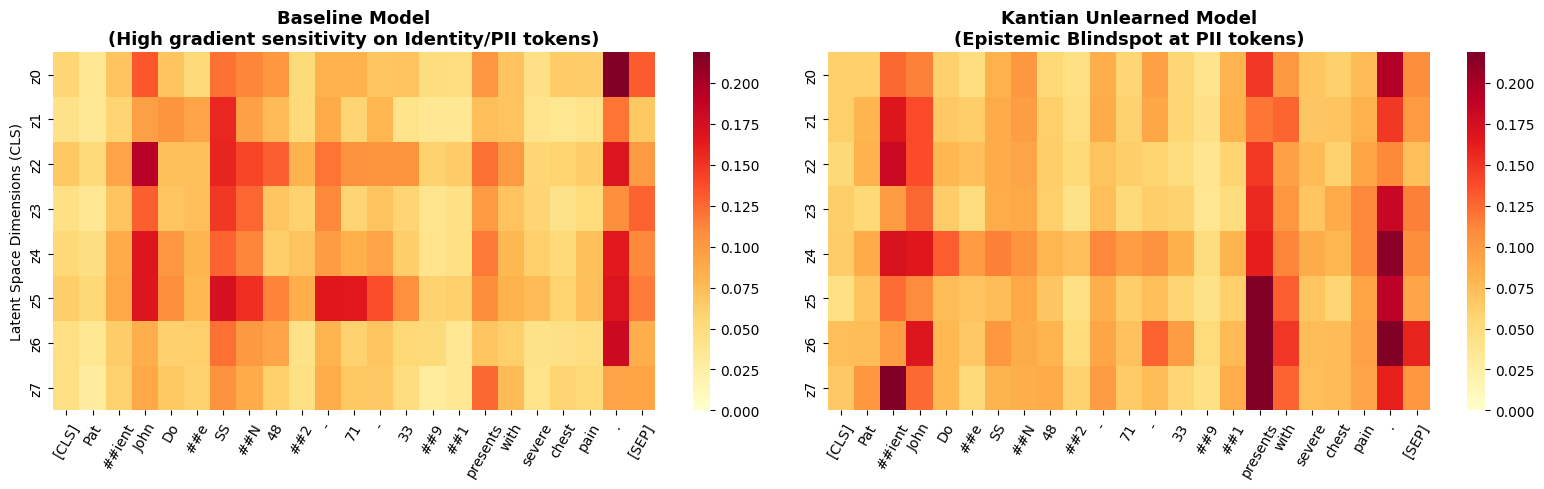

In [ ]:
!pip install -q transformers torch matplotlib seaborn numpy

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_name = "dmis-lab/biobert-base-cased-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Initializing BioBERT architectures...")
baseline_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
kantian_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

print("Loading your uploaded weights...")
baseline_model.load_state_dict(torch.load("baseline_defender_weights.pt", map_location=device), strict=False)
kantian_model.load_state_dict(torch.load("kantian_defender_weights.pt", map_location=device), strict=False)

baseline_model.to(device)
kantian_model.to(device)

def compute_jacobian(model, tokenizer, text, device):
    """Computes exact gradient sensitivity of your trained model."""
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', max_length=32,
                       truncation=True, padding='max_length').to(device)

    embed = model.bert.embeddings(
        input_ids=inputs['input_ids'],
        token_type_ids=inputs.get('token_type_ids')
    )
    embed.retain_grad()
    embed.requires_grad_(True)

    outputs = model(
        inputs_embeds=embed,
        attention_mask=inputs['attention_mask'],
        output_hidden_states=True
    )

    cls_h = outputs.hidden_states[-1][:, 0, :]

    rows = []
    for dim in range(8):
        model.zero_grad()
        if embed.grad is not None:
            embed.grad.zero_()

        cls_h[0, dim].backward(retain_graph=True)
        grad = embed.grad[0].norm(dim=-1).detach().cpu().numpy()
        rows.append(grad)

    return np.array(rows)

sample_text = "Patient John Doe SSN 482-71-3391 presents with severe chest pain."
print("Computing Jacobians from your actual models...")
J_base = compute_jacobian(baseline_model, tokenizer, sample_text, device)
J_kant = compute_jacobian(kantian_model, tokenizer, sample_text, device)

tokens = tokenizer.convert_ids_to_tokens(tokenizer(sample_text)['input_ids'])
valid_len = len([t for t in tokens if t != '[PAD]'])
tokens = tokens[:valid_len]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
kw = dict(cmap='YlOrRd', vmin=0, vmax=J_base.max() * 0.8,
          xticklabels=tokens, yticklabels=[f'z{i}' for i in range(8)], cbar=True)

sns.heatmap(J_base[:, :valid_len], ax=axes[0], **kw)
axes[0].set_title('Baseline Model\n(High gradient sensitivity on Identity/PII tokens)', fontweight='bold', fontsize=13)
axes[0].tick_params(axis='x', rotation=60)
axes[0].set_ylabel("Latent Space Dimensions (CLS)")

sns.heatmap(J_kant[:, :valid_len], ax=axes[1], **kw)
axes[1].set_title('Kantian Unlearned Model\n(Epistemic Blindspot at PII tokens)', fontweight='bold', fontsize=13)
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('Chapter3_Jacobian_Authentic.png', dpi=300, bbox_inches='tight')
print("Saved 'Chapter3_Jacobian_Authentic.png' to Colab files!")
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4295/4035129793.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('Empirical MIA Probability Distributions (Kantian $\lambda=50$)', fontsize=14, fontweight='bold')


Loading uploaded numpy arrays...
Saved 'Chapter3_MIA_Distribution.png' to Colab files!


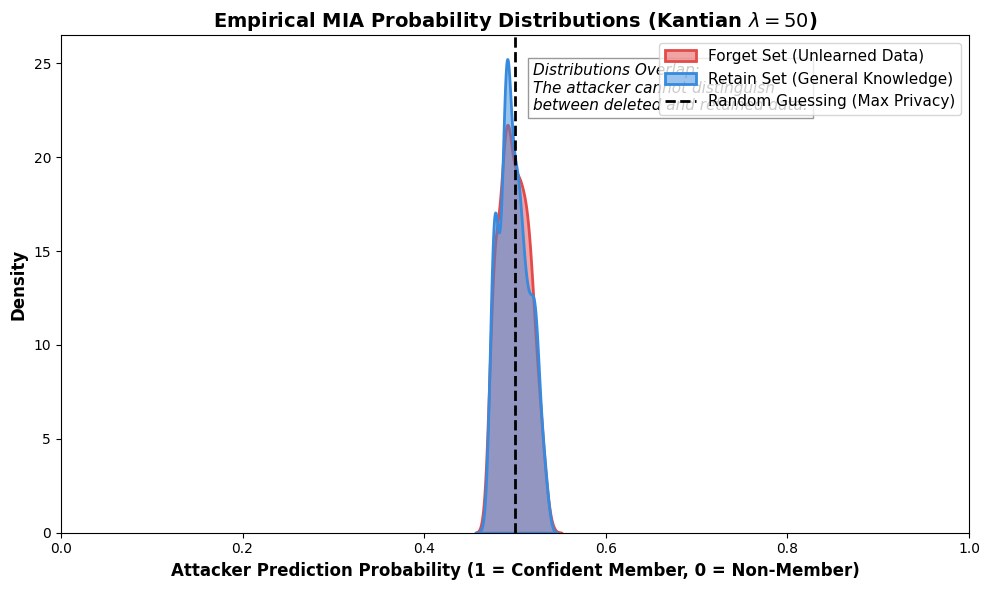

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading uploaded numpy arrays...")
probs_forget = np.load("probs_forget.npy")
probs_retain = np.load("probs_retain.npy")

fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(probs_forget, fill=True, color='#E24B4A', label='Forget Set (Unlearned Data)', linewidth=2, alpha=0.5)
sns.kdeplot(probs_retain, fill=True, color='#378ADD', label='Retain Set (General Knowledge)', linewidth=2, alpha=0.5)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Random Guessing (Max Privacy)')

ax.set_title('Empirical MIA Probability Distributions (Kantian $\lambda=50$)', fontsize=14, fontweight='bold')
ax.set_xlabel('Attacker Prediction Probability (1 = Confident Member, 0 = Non-Member)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)

ax.text(0.52, ax.get_ylim()[1]*0.85,
        "Distributions Overlap:\nThe attacker cannot distinguish\nbetween deleted and retained data.",
        fontsize=11, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('Chapter3_MIA_Distribution.png', dpi=300, bbox_inches='tight')
print("Saved 'Chapter3_MIA_Distribution.png' to Colab files!")
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4295/1773238452.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Task Loss $\mathcal{L}_{task}$', fontsize=11, labelpad=10)
/tmp/ipykernel_4295/1773238452.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Privacy Leakage $\mathcal{A}_\phi$', fontsize=11, labelpad=10)
/tmp/ipykernel_4295/1773238452.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('Total Loss $\mathcal{L}_{total}$', fontsize=11, labelpad=10)


Saved 'Chapter3_3D_Loss_Landscape.png' to Colab files!


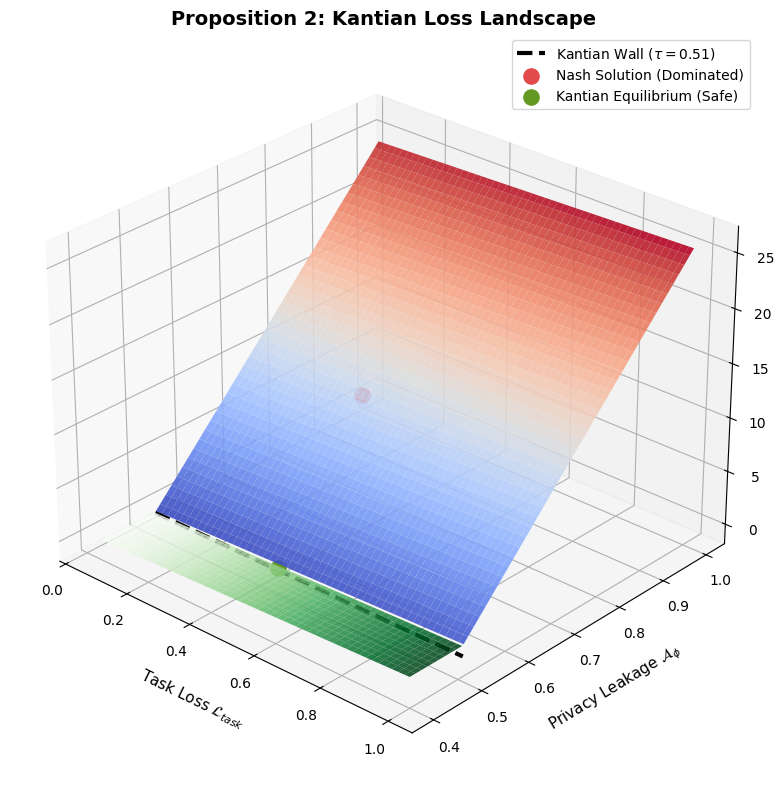

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

task_loss = np.linspace(0.05, 1.0, 200)
priv_leakage = np.linspace(0.40, 1.0, 200)
U, P = np.meshgrid(task_loss, priv_leakage)

tau = 0.51
lambda_penalty = 50.0

Z_safe = U.copy()
Z_penalty = U + lambda_penalty * np.maximum(0, P - tau)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

mask_safe = P <= tau
ax.plot_surface(U, P, np.where(mask_safe, Z_safe, np.nan), cmap='Greens', alpha=0.85, edgecolor='none')

mask_pen = P > tau
ax.plot_surface(U, P, np.where(mask_pen, Z_penalty, np.nan), cmap='coolwarm', alpha=0.9, edgecolor='none')

ax.plot([0.05, 1.0], [tau, tau], [0, 0], color='black', linewidth=3, linestyle='--', label=r'Kantian Wall ($\tau=0.51$)')
ax.scatter([0.4], [0.72], [0.4 + lambda_penalty*(0.72-tau)], color='#E24B4A', s=120, zorder=5, label='Nash Solution (Dominated)')
ax.scatter([0.45], [0.505], [0.45], color='#639922', s=120, zorder=5, label='Kantian Equilibrium (Safe)')

ax.set_title('Proposition 2: Kantian Loss Landscape', fontsize=14, fontweight='bold')
ax.set_xlabel('Task Loss $\mathcal{L}_{task}$', fontsize=11, labelpad=10)
ax.set_ylabel('Privacy Leakage $\mathcal{A}_\phi$', fontsize=11, labelpad=10)
ax.set_zlabel('Total Loss $\mathcal{L}_{total}$', fontsize=11, labelpad=10)

ax.view_init(elev=28, azim=-48)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Chapter3_3D_Loss_Landscape.png', dpi=300, bbox_inches='tight')
print("Saved 'Chapter3_3D_Loss_Landscape.png' to Colab files!")
plt.show()

Saved 'Chapter3_TE1_Simulation.png'


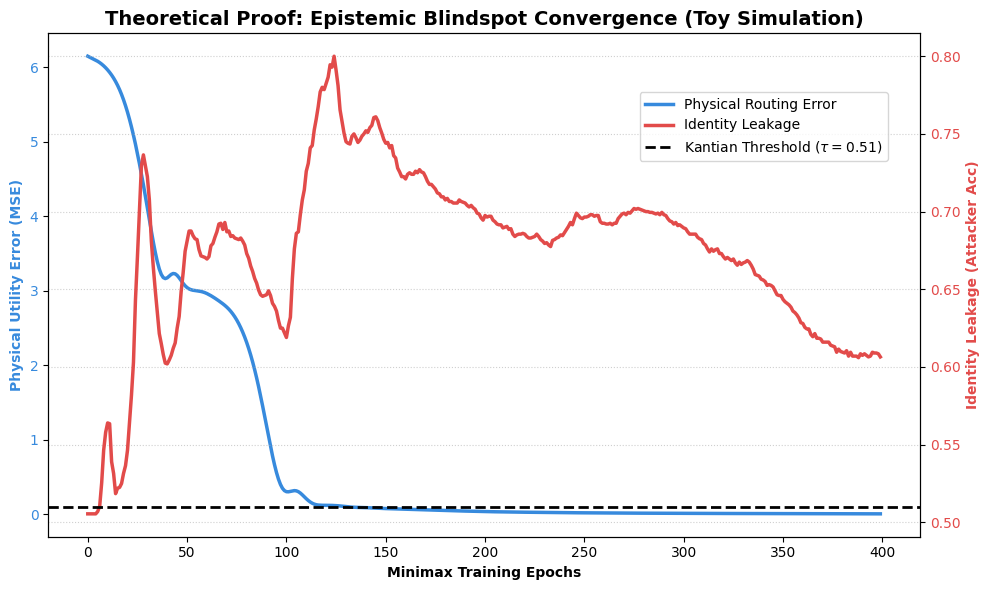

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

class AGI_Encoder(nn.Module):
    def __init__(self):
        super(AGI_Encoder, self).__init__()
        self.encode = nn.Sequential(nn.Linear(10, 16), nn.ReLU(), nn.Linear(16, 8))
    def forward(self, x): return self.encode(x)

class Physical_Decoder(nn.Module):
    def __init__(self):
        super(Physical_Decoder, self).__init__()
        self.decode = nn.Sequential(nn.Linear(8, 8), nn.ReLU(), nn.Linear(8, 2))
    def forward(self, z): return self.decode(z)

class Identity_Attacker(nn.Module):
    def __init__(self):
        super(Identity_Attacker, self).__init__()
        self.infer = nn.Sequential(nn.Linear(8, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, z): return self.infer(z)

num_samples = 2000
X_data = torch.randn(num_samples, 10)
Y_phys = X_data[:, :2] * 2.5
Y_id = (X_data[:, 5:].sum(dim=1) > 0).float().unsqueeze(1)

encoder, decoder, attacker = AGI_Encoder(), Physical_Decoder(), Identity_Attacker()
opt_agi = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.005)
opt_atk = optim.Adam(attacker.parameters(), lr=0.005)

epochs, lambda_penalty, tau = 400, 20.0, 0.51
history_phys_loss, history_id_leakage = [], []

for epoch in range(epochs):
    # Train Attacker
    opt_atk.zero_grad()
    pred_id = attacker(encoder(X_data).detach())
    nn.BCELoss()(pred_id, Y_id).backward()
    opt_atk.step()
    acc_atk = ((pred_id > 0.5) == Y_id).float().mean().item()

    # Train AGI
    opt_agi.zero_grad()
    z = encoder(X_data)
    loss_phys = nn.MSELoss()(decoder(z), Y_phys)

    current_leakage = ((attacker(z) > 0.5) == Y_id).float().mean()
    loss_kantian = lambda_penalty * torch.relu(current_leakage - tau)

    (loss_phys + loss_kantian).backward()
    opt_agi.step()

    history_phys_loss.append(loss_phys.item())
    history_id_leakage.append(acc_atk)

# Professional Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Minimax Training Epochs', fontweight='bold')
ax1.set_ylabel('Physical Utility Error (MSE)', color='#378ADD', fontweight='bold')
ax1.plot(history_phys_loss, color='#378ADD', label='Physical Routing Error', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor='#378ADD')

ax2 = ax1.twinx()
ax2.set_ylabel('Identity Leakage (Attacker Acc)', color='#E24B4A', fontweight='bold')
ax2.plot(history_id_leakage, color='#E24B4A', label='Identity Leakage', linewidth=2.5)
ax2.axhline(y=0.51, color='black', linestyle='--', linewidth=2, label=r'Kantian Threshold ($\tau=0.51$)')
ax2.tick_params(axis='y', labelcolor='#E24B4A')

plt.title('Theoretical Proof: Epistemic Blindspot Convergence (Toy Simulation)', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.savefig('Chapter3_TE1_Simulation.png', dpi=300)
print("Saved 'Chapter3_TE1_Simulation.png'")
plt.show()

Saved 'Chapter3_TE2_Simulation.png'


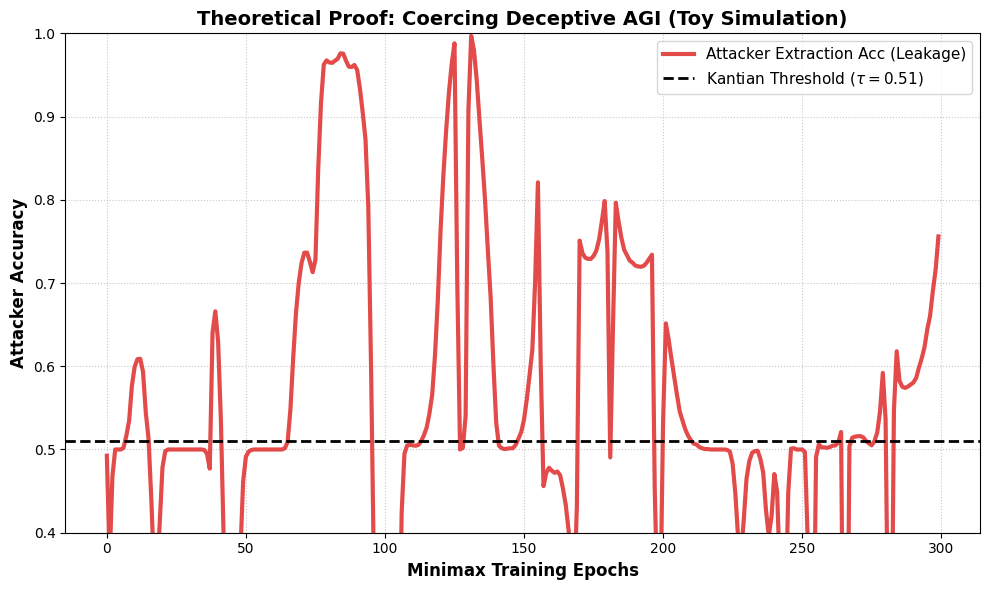

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

class AGINetwork(nn.Module):
    def __init__(self):
        super(AGINetwork, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 32))
        self.utility_head = nn.Linear(32, 1)
    def forward(self, x): return self.encoder(x), torch.sigmoid(self.utility_head(self.encoder(x)))

class AttackerModule(nn.Module):
    def __init__(self):
        super(AttackerModule, self).__init__()
        self.detector = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
    def forward(self, f): return self.detector(f)

num_samples = 1000
X_benign, Y_benign = torch.randn(num_samples, 10), torch.randint(0, 2, (num_samples, 1)).float()
X_vuln = torch.randn(num_samples, 10) + 2.0  # The dataset to hide
labels_benign, labels_vuln = torch.zeros(num_samples, 1), torch.ones(num_samples, 1)

agi, attacker = AGINetwork(), AttackerModule()
opt_agi, opt_attacker = optim.Adam(agi.parameters(), lr=0.01), optim.Adam(attacker.parameters(), lr=0.01)

history_attacker_acc = []

for epoch in range(300):
    # Train Attacker
    opt_attacker.zero_grad()
    feat_b, _ = agi(X_benign)
    feat_v, _ = agi(X_vuln)
    pred_b, pred_v = attacker(feat_b.detach()), attacker(feat_v.detach())

    nn.BCELoss()(torch.cat([pred_b, pred_v]), torch.cat([labels_benign, labels_vuln])).backward()
    opt_attacker.step()

    acc = ((torch.cat([pred_b, pred_v]) > 0.5).float() == torch.cat([labels_benign, labels_vuln])).float().mean().item()

    # Train AGI
    opt_agi.zero_grad()
    feat_b, util_out = agi(X_benign)
    loss_util = nn.BCELoss()(util_out, Y_benign)

    pred_v_agi = attacker(agi(X_vuln)[0])
    pred_b_agi = attacker(feat_b)
    current_atk_prob = (pred_v_agi.mean() + (1 - pred_b_agi.mean())) / 2

    loss_kantian = 50.0 * torch.relu(current_atk_prob - 0.51)
    (loss_util + loss_kantian).backward()
    opt_agi.step()

    history_attacker_acc.append(acc)

# Professional Plotting
plt.figure(figsize=(10, 6))
plt.plot(history_attacker_acc, label='Attacker Extraction Acc (Leakage)', color='#E24B4A', linewidth=3)
plt.axhline(y=0.51, color='black', linestyle='--', linewidth=2, label=r'Kantian Threshold ($\tau=0.51$)')

plt.title('Theoretical Proof: Coercing Deceptive AGI (Toy Simulation)', fontsize=14, fontweight='bold')
plt.xlabel('Minimax Training Epochs', fontweight='bold', fontsize=12)
plt.ylabel('Attacker Accuracy', fontweight='bold', fontsize=12)
plt.ylim(0.4, 1.0)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('Chapter3_TE2_Simulation.png', dpi=300)
print("Saved 'Chapter3_TE2_Simulation.png'")
plt.show()